# 20. SAM2 Human-in-the-Loop 잎 어노테이터

**목적**: 이미지를 보면서 잎을 클릭 → SAM2가 마스크 생성 → YOLO v11 seg용 polygon txt 저장

**조작법**:
- **Left-click** 이미지 위 잎 중심 → SAM2 마스크 미리보기
- **Right-click** → 해당 위치를 negative point로 추가 (마스크 제외 영역 지정)
- **Add Leaf** → 현재 마스크를 확정하고 다음 잎으로
- **Clear** → 현재 잎의 포인트 초기화
- **Save** → 확정된 모든 마스크를 YOLO txt로 저장, parquet 업데이트
- **Skip** → 이 이미지 건너뜀
- **Prev / Next** → 이미지 탐색

In [1]:
%matplotlib widget
import os, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path
from PIL import Image

warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
    ROOT = Path('/content')
except ImportError:
    IN_COLAB = False
    ROOT = Path(os.getcwd()).parent

DATASET_DIR = ROOT / 'dataset' / 'collector'
LABELS_DIR  = DATASET_DIR / 'yolo_labels'
LABELS_DIR.mkdir(parents=True, exist_ok=True)

SAM2_CKPT_DIR  = ROOT / 'checkpoints'
SAM2_CKPT_DIR.mkdir(exist_ok=True)
SAM2_CKPT_PATH = SAM2_CKPT_DIR / 'sam2.1_hiera_small.pt'
SAM2_CFG       = 'configs/sam2.1/sam2.1_hiera_s.yaml'

LEAF_CLASS_ID  = 0

print(f'ROOT       : {ROOT}')
print(f'LABELS_DIR : {LABELS_DIR}')
print(f'CKPT       : {SAM2_CKPT_PATH}')

ROOT       : /Users/mainframe/Workspace/Graduates/planta-gochi-ML
LABELS_DIR : /Users/mainframe/Workspace/Graduates/planta-gochi-ML/dataset/collector/yolo_labels
CKPT       : /Users/mainframe/Workspace/Graduates/planta-gochi-ML/checkpoints/sam2.1_hiera_small.pt


In [2]:
# SAM2 체크포인트 다운로드 (없을 때만)
import urllib.request

CKPT_URL = (
    'https://dl.fbaipublicfiles.com/segment_anything_2/092824/'
    'sam2.1_hiera_small.pt'
)

if not SAM2_CKPT_PATH.exists():
    print('체크포인트 다운로드 중...')
    def _progress(block, block_size, total):
        pct = block * block_size / total * 100
        print(f'\r  {pct:.1f}%', end='', flush=True)
    urllib.request.urlretrieve(CKPT_URL, SAM2_CKPT_PATH, reporthook=_progress)
    print('\n완료')
else:
    print(f'체크포인트 존재: {SAM2_CKPT_PATH}')

체크포인트 존재: /Users/mainframe/Workspace/Graduates/planta-gochi-ML/checkpoints/sam2.1_hiera_small.pt


In [3]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {DEVICE}')

sam2_model = build_sam2(SAM2_CFG, SAM2_CKPT_PATH, device=DEVICE)
predictor  = SAM2ImagePredictor(sam2_model)
print('SAM2 로드 완료')

Device: mps
SAM2 로드 완료


In [4]:
# 분할별 parquet 로드 & 어노테이션 컬럼 초기화
splits = ['train', 'val', 'test']
parquet_paths = {s: DATASET_DIR / f'{s}.parquet' for s in splits}

dfs = {s: pd.read_parquet(p) for s, p in parquet_paths.items()}

for s, df in dfs.items():
    if 'yolo_label_path' not in df.columns:
        df['yolo_label_path'] = None
    if 'leaf_count' not in df.columns:
        df['leaf_count'] = pd.NA

df_all = pd.concat(dfs.values(), ignore_index=True)
print(f'전체 이미지: {len(df_all)}')
print(f'어노테이션 완료: {df_all["yolo_label_path"].notna().sum()}')

전체 이미지: 1961
어노테이션 완료: 0


In [5]:
# ── 헬퍼 함수 & 상수 ─────────────────────────────────────────────────────────

COLORS       = plt.cm.tab10.colors
PREVIEW_COLOR = (1.0, 0.0, 0.9)   # 마젠타
NIGHT_LUX    = 10.0                # 조도 ≤ 이 값 → 야간으로 분류, 자동 스킵

def mask_to_yolo_polygon(mask: np.ndarray, img_h: int, img_w: int) -> str | None:
    m = (mask.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 10:
        return None
    epsilon = 0.003 * cv2.arcLength(largest, True)
    approx  = cv2.approxPolyDP(largest, epsilon, True).reshape(-1, 2)
    if len(approx) < 3:
        return None
    pts_norm = np.clip(approx / np.array([img_w, img_h], dtype=float), 0.0, 1.0)
    coords   = ' '.join(f'{v:.6f}' for v in pts_norm.flatten())
    return f'{LEAF_CLASS_ID} {coords}'


def save_yolo_label(label_path: Path, yolo_lines: list[str]) -> None:
    label_path.parent.mkdir(parents=True, exist_ok=True)
    label_path.write_text('\n'.join(yolo_lines) + '\n')


def update_parquets(dfs: dict, df_all: pd.DataFrame, parquet_paths: dict) -> None:
    for s, df in dfs.items():
        idx = df_all[df_all['split'] == s].index
        df['yolo_label_path'] = df_all.loc[idx, 'yolo_label_path'].values
        df['leaf_count']      = df_all.loc[idx, 'leaf_count'].values
        df.to_parquet(parquet_paths[s], index=False)


def blend_mask(image_rgb: np.ndarray, mask: np.ndarray,
               color: tuple, alpha: float) -> np.ndarray:
    out  = image_rgb.astype(np.float32)
    m    = mask.astype(bool)
    c255 = np.array([color[0]*255, color[1]*255, color[2]*255], dtype=np.float32)
    out[m] = (1 - alpha) * out[m] + alpha * c255
    return np.clip(out, 0, 255).astype(np.uint8)


def draw_contour_halo(ax, mask: np.ndarray, color,
                      lw: float = 3.0, linestyle: str = '-') -> None:
    m = mask.astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in contours:
        pts = c.reshape(-1, 2)
        xs  = np.append(pts[:, 0], pts[0, 0])
        ys  = np.append(pts[:, 1], pts[0, 1])
        ax.plot(xs, ys, color='white', lw=lw + 2.5, linestyle=linestyle,
                zorder=3, solid_capstyle='round')
        ax.plot(xs, ys, color=color,   lw=lw,        linestyle=linestyle,
                zorder=4, solid_capstyle='round')

In [6]:
class LeafAnnotator:
    """ipywidgets + matplotlib widget 기반 Human-in-the-Loop 어노테이터."""

    def __init__(self, df_all, predictor, dfs, parquet_paths):
        self.df        = df_all.reset_index(drop=True)
        self.predictor = predictor
        self.dfs       = dfs
        self.pq_paths  = parquet_paths
        self.idx       = self._first_unannotated()

        self._image_rgb: np.ndarray | None = None
        self._pos_pts: list[tuple] = []
        self._neg_pts: list[tuple] = []
        self._current_mask: np.ndarray | None = None
        self._confirmed_masks: list[np.ndarray] = []

        self._build_ui()
        self._load_image()

    # ── UI ───────────────────────────────────────────────────────────────────

    def _build_ui(self):
        self.fig, self.ax = plt.subplots(figsize=(11, 6.5))
        self.fig.subplots_adjust(left=0.01, right=0.99, top=0.97, bottom=0.03)
        self.fig.canvas.mpl_connect('button_press_event', self._on_click)

        btn_kw = dict(layout=widgets.Layout(width='130px', height='36px'))
        self.btn_add     = widgets.Button(description='✅ Add Leaf',     button_style='success', **btn_kw)
        self.btn_undo    = widgets.Button(description='↩ Undo Leaf',    button_style='danger',  **btn_kw)
        self.btn_save    = widgets.Button(description='💾 Save',         button_style='primary', **btn_kw)
        self.btn_skip    = widgets.Button(description='⏭ Skip',          button_style='',        **btn_kw)
        self.btn_clr_pts = widgets.Button(description='🔄 Clear Points', button_style='warning', **btn_kw)
        self.btn_reset   = widgets.Button(description='🗑 Reset Label',  button_style='danger',  **btn_kw)
        self.btn_prev    = widgets.Button(description='◀ Prev',          button_style='',        **btn_kw)
        self.btn_next    = widgets.Button(description='Next ▶',          button_style='',        **btn_kw)

        self.btn_add.on_click(self._on_add)
        self.btn_undo.on_click(self._on_undo_leaf)
        self.btn_save.on_click(self._on_save)
        self.btn_skip.on_click(self._on_skip)
        self.btn_clr_pts.on_click(self._on_clear_pts)
        self.btn_reset.on_click(self._on_reset)
        self.btn_prev.on_click(lambda _: self._nav(-1))
        self.btn_next.on_click(lambda _: self._nav(+1))

        self.lbl_points = widgets.HTML(value='')
        self.lbl_status = widgets.HTML(value='')
        self.lbl_info   = widgets.HTML(value='')

        row1    = widgets.HBox([self.btn_add, self.btn_undo, self.btn_save, self.btn_skip])
        row2    = widgets.HBox([self.btn_clr_pts, self.btn_reset,
                                widgets.Label('   '), self.btn_prev, self.btn_next])
        self.ui = widgets.VBox([row1, row2, self.lbl_points, self.lbl_status, self.lbl_info])
        display(self.ui)
        self._refresh_point_label()

    # ── 포인트 카운터 ─────────────────────────────────────────────────────────

    def _refresh_point_label(self):
        pos = len(self._pos_pts)
        neg = len(self._neg_pts)
        n   = len(self._confirmed_masks)
        self.lbl_points.value = (
            '<div style="font-family:monospace;font-size:13px;'
            'background:#f5f5f5;padding:5px 10px;border-radius:6px;margin:3px 0">'
            f'<b>확정된 잎:</b> {n}개 &nbsp;｜&nbsp; '
            f'<b>현재 포인트:</b> '
            f'<span style="color:green;font-weight:bold">● 포함 {pos}개</span>'
            f'&nbsp; '
            f'<span style="color:crimson;font-weight:bold">✕ 제외 {neg}개</span>'
            '</div>'
        )

    # ── 이미지 로드 ──────────────────────────────────────────────────────────

    def _first_unannotated(self) -> int:
        unannotated = self.df[self.df['yolo_label_path'].isna()].index
        return int(unannotated[0]) if len(unannotated) else 0

    def _is_night(self, row) -> bool:
        return float(row['light']) <= NIGHT_LUX

    def _load_image(self):
        if self.idx < 0 or self.idx >= len(self.df):
            self._set_status('📋 모든 이미지를 검토했습니다!', 'purple')
            return

        row = self.df.iloc[self.idx]

        # ── 야간 자동 마킹: 미어노테이션 상태인 야간 사진만 처리 ──────────────
        if pd.isna(row['yolo_label_path']) and self._is_night(row):
            self.df.at[self.idx, 'yolo_label_path'] = 'night'
            self.df.at[self.idx, 'leaf_count']      = 0
            update_parquets(self.dfs, self.df, self.pq_paths)
            self._nav(+1)   # 다음 이미지로 자동 이동
            return

        img = Image.open(row['image_path']).convert('RGB')
        self._image_rgb = np.array(img)
        self._pos_pts.clear()
        self._neg_pts.clear()
        self._current_mask = None
        self._confirmed_masks.clear()

        self.predictor.set_image(self._image_rgb)
        self._redraw()
        self._refresh_point_label()
        self._update_info_label(row)

        # 이미 어노테이션된 이미지로 돌아온 경우 상태 표시
        lp = row['yolo_label_path']
        if pd.notna(lp) and lp != 'night':
            self._set_status(
                f'✅ 이미 저장된 라벨 있음 (잎 {int(row["leaf_count"])}개) — '
                f'재작업하려면 🗑 Reset Label 후 다시 어노테이션하세요.', '#888'
            )
        else:
            self._set_status('🖱 잎 위를 클릭하세요  (좌클릭=포함, 우클릭=제외)', '#333')

    def _update_info_label(self, row):
        annotated = self.df['yolo_label_path'].notna().sum()
        night_cnt = (self.df['yolo_label_path'] == 'night').sum()
        fname     = row['image_filename']
        lp        = row['yolo_label_path']
        tag = ''
        if pd.notna(lp):
            tag = '&nbsp;<span style="color:#888">[완료]</span>' if lp != 'night' \
                  else '&nbsp;<span style="color:#999">[야간]</span>'
        self.lbl_info.value = (
            f'<span style="font-size:12px;color:#555">'
            f'<b>[{self.idx+1}/{len(self.df)}]</b> '
            f'{fname}{tag} &nbsp;|&nbsp; '
            f'시간: {fname[8:10]}시 {fname[10:12]}분 &nbsp;|&nbsp; '
            f'조도: {row["light"]} &nbsp;|&nbsp; '
            f'split: {row["split"]} &nbsp;|&nbsp; '
            f'완료: {annotated - night_cnt}개 · 야간스킵: {night_cnt}개 / {len(self.df)}'
            f'</span>'
        )

    # ── 클릭 이벤트 ──────────────────────────────────────────────────────────

    def _on_click(self, event):
        if event.inaxes is not self.ax or event.xdata is None:
            return
        x, y = int(round(event.xdata)), int(round(event.ydata))
        if event.button == 1:
            self._pos_pts.append((x, y))
        elif event.button == 3:
            self._neg_pts.append((x, y))
        else:
            return
        self._refresh_point_label()
        self._redraw()
        self._run_sam2()

    def _run_sam2(self):
        if not self._pos_pts:
            return
        all_pts    = self._pos_pts + self._neg_pts
        all_labels = [1] * len(self._pos_pts) + [0] * len(self._neg_pts)

        masks, scores, _ = self.predictor.predict(
            point_coords=np.array(all_pts,    dtype=float),
            point_labels=np.array(all_labels, dtype=int),
            multimask_output=True,
        )
        self._current_mask = masks[int(np.argmax(scores))]
        self._redraw()
        self._set_status(
            f'마스크 생성 완료 (score={scores.max():.3f}) — '
            f'마음에 들면 ✅ Add Leaf | 포인트 추가로 보정 | 초기화: 🔄 Clear Points',
            'steelblue'
        )

    # ── 렌더링 ────────────────────────────────────────────────────────────────

    def _redraw(self):
        self.ax.cla()
        display_img = self._image_rgb.copy()

        for i, mask in enumerate(self._confirmed_masks):
            display_img = blend_mask(display_img, mask, COLORS[i % len(COLORS)], alpha=0.45)
        if self._current_mask is not None:
            display_img = blend_mask(display_img, self._current_mask, PREVIEW_COLOR, alpha=0.60)

        self.ax.imshow(display_img)
        self.ax.axis('off')

        for i, mask in enumerate(self._confirmed_masks):
            draw_contour_halo(self.ax, mask, COLORS[i % len(COLORS)], lw=2.5)
        if self._current_mask is not None:
            draw_contour_halo(self.ax, self._current_mask, PREVIEW_COLOR, lw=3.0, linestyle='--')

        for i, (px, py) in enumerate(self._pos_pts):
            self.ax.plot(px, py, 'o', color='limegreen',
                         markersize=18, markeredgecolor='white', markeredgewidth=2, zorder=5)
            self.ax.text(px, py, str(i+1), color='black',
                         fontsize=9, fontweight='bold', ha='center', va='center', zorder=6)
        for i, (px, py) in enumerate(self._neg_pts):
            self.ax.plot(px, py, 'X', color='crimson',
                         markersize=18, markeredgecolor='white', markeredgewidth=2, zorder=5)
            self.ax.text(px, py, str(i+1), color='white',
                         fontsize=8, fontweight='bold', ha='center', va='center', zorder=6)

        for i, mask in enumerate(self._confirmed_masks):
            ys, xs = np.where(mask.astype(bool))
            if len(xs):
                cx, cy = int(xs.mean()), int(ys.mean())
                color  = COLORS[i % len(COLORS)]
                self.ax.text(cx, cy, f'Leaf {i+1}',
                             color='white', fontsize=10, fontweight='bold',
                             ha='center', va='center', zorder=7,
                             bbox=dict(boxstyle='round,pad=0.25', fc=color, alpha=0.8, lw=0))

        patches = [mpatches.Patch(color=COLORS[i % len(COLORS)], label=f'Leaf {i+1}')
                   for i in range(len(self._confirmed_masks))]
        if self._current_mask is not None:
            patches.append(mpatches.Patch(color=PREVIEW_COLOR, label='미리보기'))
        if patches:
            self.ax.legend(handles=patches, loc='upper right', fontsize=9,
                           framealpha=0.85, edgecolor='#aaa')

        self.fig.canvas.draw_idle()

    # ── 버튼 콜백 ────────────────────────────────────────────────────────────

    def _on_add(self, _):
        if self._current_mask is None:
            self._set_status('⚠ 먼저 이미지를 클릭해 마스크를 생성하세요.', 'red')
            return
        self._confirmed_masks.append(self._current_mask.copy())
        self._current_mask = None
        self._pos_pts.clear()
        self._neg_pts.clear()
        self._refresh_point_label()
        self._redraw()
        self._set_status(f'✅ Leaf {len(self._confirmed_masks)} 확정 — 다음 잎을 클릭하거나 💾 Save 하세요.', 'green')

    def _on_undo_leaf(self, _):
        if not self._confirmed_masks:
            self._set_status('⚠ 취소할 잎이 없습니다.', 'red')
            return
        self._confirmed_masks.pop()
        self._refresh_point_label()
        self._redraw()
        self._set_status(f'↩ 마지막 잎 취소 — 현재 확정: {len(self._confirmed_masks)}개', 'darkorange')

    def _on_clear_pts(self, _):
        self._pos_pts.clear()
        self._neg_pts.clear()
        self._current_mask = None
        self._refresh_point_label()
        self._redraw()
        self._set_status('🔄 포인트 초기화 — 다시 클릭하세요.', 'darkorange')

    def _on_reset(self, _):
        """현재 이미지의 라벨 데이터 완전 초기화 (txt 파일 삭제 + parquet 갱신)."""
        row = self.df.iloc[self.idx]
        lp  = row['yolo_label_path']

        # txt 파일 삭제 (night 마킹이나 실제 파일인 경우만)
        if pd.notna(lp) and lp != 'night':
            p = Path(lp)
            if p.exists():
                p.unlink()

        self.df.at[self.idx, 'yolo_label_path'] = None
        self.df.at[self.idx, 'leaf_count']      = pd.NA
        update_parquets(self.dfs, self.df, self.pq_paths)

        # 상태 초기화 후 현재 이미지 재로드
        self._pos_pts.clear()
        self._neg_pts.clear()
        self._current_mask = None
        self._confirmed_masks.clear()
        self._refresh_point_label()

        # 야간 이미지를 reset하면 다시 야간으로 마킹되므로 안내
        if self._is_night(row):
            self._set_status(
                f'🗑 라벨 초기화 완료 — 조도 {row["light"]} (야간 기준 {NIGHT_LUX} 이하)'
                f' → 다시 저장하면 야간으로 재마킹됩니다.', 'darkorange'
            )
        else:
            self.predictor.set_image(np.array(Image.open(row['image_path']).convert('RGB')))
            self._redraw()
            self._update_info_label(self.df.iloc[self.idx])
            self._set_status('🗑 라벨 초기화 완료 — 다시 어노테이션하세요.', 'darkorange')

    def _on_save(self, _):
        if not self._confirmed_masks:
            self._set_status('⚠ 확정된 마스크가 없습니다. Add Leaf 먼저 하세요.', 'red')
            return
        row      = self.df.iloc[self.idx]
        h, w     = self._image_rgb.shape[:2]
        stem     = Path(row['image_filename']).stem
        lbl_path = LABELS_DIR / f'{stem}.txt'

        lines = [l for mask in self._confirmed_masks
                 if (l := mask_to_yolo_polygon(mask, h, w)) is not None]
        if not lines:
            self._set_status('⚠ 유효한 폴리곤이 없습니다. 마스크를 다시 생성하세요.', 'red')
            return

        save_yolo_label(lbl_path, lines)
        self.df.at[self.idx, 'yolo_label_path'] = str(lbl_path)
        self.df.at[self.idx, 'leaf_count']      = len(lines)
        update_parquets(self.dfs, self.df, self.pq_paths)
        self._set_status(f'💾 저장 완료! 잎 {len(lines)}개 → {lbl_path.name}', 'green')
        self._nav(+1)

    def _on_skip(self, _):
        self._set_status('⏭ 건너뜀', 'gray')
        self._nav(+1)

    def _nav(self, delta: int):
        new_idx = self.idx + delta
        if 0 <= new_idx < len(self.df):
            self.idx = new_idx
            self._load_image()
        else:
            self._set_status('📋 모든 이미지를 검토했습니다!', 'purple')

    def _set_status(self, msg: str, color: str = '#333'):
        self.lbl_status.value = f'<div style="font-size:13px;padding:3px 0;color:{color}">{msg}</div>'

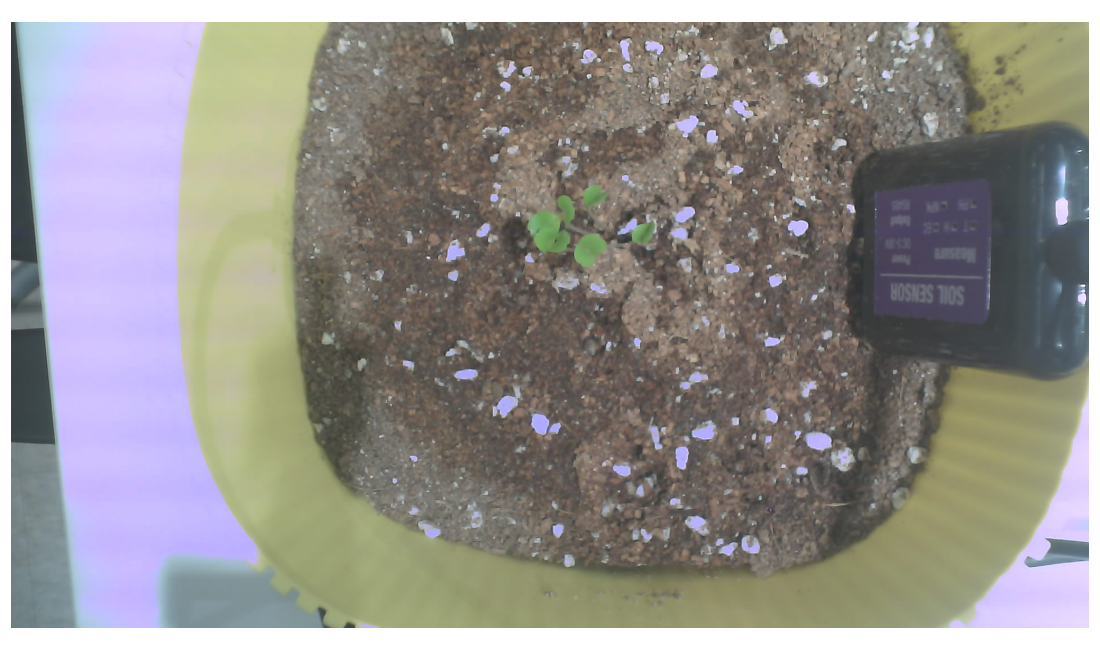

In [7]:
%matplotlib widget
# 어노테이터 실행
annotator = LeafAnnotator(df_all, predictor, dfs, parquet_paths)

In [ ]:
# ── 마스크 진단 셀 (문제 발생 시 실행) ────────────────────────────────────────
# annotator 실행 후 클릭이 안 보이면 이 셀로 mask 상태를 확인하세요
import traceback

def diagnose(annotator):
    m = annotator._current_mask
    if m is None:
        print('_current_mask = None (아직 클릭 안 했거나 SAM2 미실행)')
        return

    print(f'dtype  : {m.dtype}')
    print(f'shape  : {m.shape}')
    print(f'unique : {np.unique(m)}')
    print(f'True px: {m.astype(bool).sum()} / {m.size}')

    # blend_mask 단독 테스트
    try:
        result = blend_mask(annotator._image_rgb, m, PREVIEW_COLOR, alpha=0.60)
        print(f'blend_mask OK → output shape {result.shape} dtype {result.dtype}')
    except Exception:
        print('blend_mask 오류:')
        traceback.print_exc()

    # draw_contour_halo 단독 테스트
    fig_t, ax_t = plt.subplots(1, 1, figsize=(6, 4))
    try:
        result = blend_mask(annotator._image_rgb, m, PREVIEW_COLOR, alpha=0.60)
        ax_t.imshow(result)
        draw_contour_halo(ax_t, m, PREVIEW_COLOR, lw=3)
        ax_t.set_title('진단: blend_mask + contour')
        ax_t.axis('off')
        print('draw_contour_halo OK')
    except Exception:
        print('draw_contour_halo 오류:')
        traceback.print_exc()
    plt.show()

# 사용법: 클릭 후 아래 주석 해제
# diagnose(annotator)

In [ ]:
# 진행 현황 확인 (언제든 실행 가능)
df_check  = pd.concat([pd.read_parquet(p) for p in parquet_paths.values()], ignore_index=True)
total     = len(df_check)
done      = (df_check['yolo_label_path'].notna() & (df_check['yolo_label_path'] != 'night')).sum()
night_cnt = (df_check['yolo_label_path'] == 'night').sum()
pending   = df_check['yolo_label_path'].isna().sum()

print(f'전체 이미지   : {total}')
print(f'어노테이션 완료: {done}  ({done/total*100:.1f}%)')
print(f'야간 자동스킵  : {night_cnt}  ({night_cnt/total*100:.1f}%)')
print(f'미처리        : {pending}')
if done > 0:
    real = df_check[df_check['yolo_label_path'].notna() & (df_check['yolo_label_path'] != 'night')]
    print(f'\n평균 잎 수: {real["leaf_count"].mean():.2f}')
    print(f'잎 수 분포:\n{real["leaf_count"].value_counts().sort_index()}')

In [ ]:
# YOLO 데이터셋 yaml 생성 (학습 준비)
import yaml, shutil

YOLO_DIR = ROOT / 'dataset' / 'yolo_seg'
for split in ['train', 'val', 'test']:
    (YOLO_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

df_check = pd.concat([pd.read_parquet(p) for p in parquet_paths.values()], ignore_index=True)

# 야간(night) 및 미처리(None) 제외 — 실제 폴리곤 라벨만 포함
annotated = df_check[
    df_check['yolo_label_path'].notna() &
    (df_check['yolo_label_path'] != 'night')
]

for _, row in annotated.iterrows():
    split    = row['split']
    img_src  = Path(row['image_path'])
    lbl_src  = Path(row['yolo_label_path'])
    img_dst  = YOLO_DIR / split / 'images' / img_src.name
    lbl_dst  = YOLO_DIR / split / 'labels' / lbl_src.name
    if not img_dst.exists():
        shutil.copy2(img_src, img_dst)
    if not lbl_dst.exists():
        shutil.copy2(lbl_src, lbl_dst)

yaml_cfg = {
    'path'  : str(YOLO_DIR),
    'train' : 'train/images',
    'val'   : 'val/images',
    'test'  : 'test/images',
    'nc'    : 1,
    'names' : ['leaf'],
}
yaml_path = YOLO_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_cfg, f, default_flow_style=False, allow_unicode=True)

print(f'YOLO 데이터셋 yaml: {yaml_path}')
print(f'학습용 이미지/라벨 쌍: {len(annotated)}')